In [1]:
import rasterio as rio
import geopandas as gpd
import pandas as pd
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report

In [11]:
# assessment_points = gpd.read_file('../data/assessment_points/assessment_points.shp')
assessment_points = gpd.read_file(r'D:\chesapeake_bay_2022_2024edition\assessment_points_shapefile_2\assessment_points.shp')
s2_tiles = gpd.read_file(r"Z:\dbcenter\dbgis\sat_tiles\sentinel2msi\tiles\all_tiles.shp").to_crs(assessment_points.crs)
points_with_tiles = gpd.sjoin(assessment_points, s2_tiles, how="left", predicate="intersects")

if points_with_tiles.index.duplicated().any():
    # 1. Extract centroids as a Series indexed by the original tile ID
    tile_centroids = s2_tiles.geometry.centroid
    
    # 2. Map the correct centroid to each point based on the 'index_right' column
    # This aligns the geometries perfectly for the distance calculation
    matched_centroids = points_with_tiles['index_right'].map(tile_centroids)
    
    # 3. Perform the distance calculation (GeoSeries vs GeoSeries)
    points_with_tiles['dist'] = points_with_tiles.geometry.distance(gpd.GeoSeries(matched_centroids, crs=points_with_tiles.crs))
    
    # 4. Deduplicate: keep the record with the minimum distance for each original point index
    points_with_tiles = points_with_tiles.sort_values('dist').groupby(level=0).head(1)

results = []

grouped = points_with_tiles.groupby(['Name', 'year'])

for (mgrs_code, year), group in tqdm(grouped, desc="Processing Tiles"):
    raster_path = f'../runs/s2_out/{year}/{mgrs_code}.tif'
    
    try:
        with rio.open(raster_path) as src:
            
            group_proj = group.to_crs(src.crs)
            
            coords = [(g.x, g.y) for g in group_proj.geometry]
            rows, cols = zip(*[src.index(x, y) for x, y in coords])
            values = [val[0] for val in src.sample(coords)]
            
            group_proj = group_proj.copy() 
            group_proj['pred_lc_class'] = values
            results.append(group_proj.to_crs(assessment_points.crs))
    except FileNotFoundError:
        print(f"Warning: Raster {raster_path} not found.")
        continue


assessment_points_final = pd.concat(results).sort_index()

Processing Tiles: 100%|██████████| 56/56 [00:07<00:00,  7.38it/s]


In [10]:
assessment_points

,lc_class,year,state,geometry
0,4,2021,VA,POINT (1412472.276 1734011.596)
1,3,2021,MD,POINT (1470186.049 1986810.253)
2,3,2021,VA,POINT (1603823.5 1845659.354)
3,1,2022,NY,POINT (1542568.429 2458417.604)
4,3,2021,VA,POINT (1514842.736 1822630.455)
...,...,...,...,...
9995,1,2021,MD,POINT (1622177.556 1904179.203)
9996,2,2021,VA,POINT (1452925.425 1715903.372)
9997,1,2021,MD,POINT (1688518.808 1994401.198)
9998,3,2022,PA,POINT (1705191.421 2064862.711)


Confusion Matrix:
[[1330   13   13    2    0]
 [  29 2486  267  106    0]
 [   9  368 4663   78    0]
 [   0  129   33  419    2]
 [   4   30    4    8    7]]
              precision    recall  f1-score   support

           1       0.97      0.98      0.97      1358
           2       0.82      0.86      0.84      2888
           3       0.94      0.91      0.92      5118
           4       0.68      0.72      0.70       583
           5       0.78      0.13      0.23        53

    accuracy                           0.89     10000
   macro avg       0.84      0.72      0.73     10000
weighted avg       0.89      0.89      0.89     10000



,User's Accuracy,Producer's Accuracy,F1 Score,N
Class,,,,
Open Water,96.94,97.94,97.44,1358
Herbaceous,82.15,86.08,84.07,2888
Forest Canopy,93.63,91.11,92.35,5118
Impervious,68.35,71.87,70.07,583
Barren Land,77.78,13.21,22.58,53
accuracy,89.05,89.05,89.05,0
macro avg,83.77,72.04,73.30,10000
weighted avg,89.21,89.05,88.98,10000


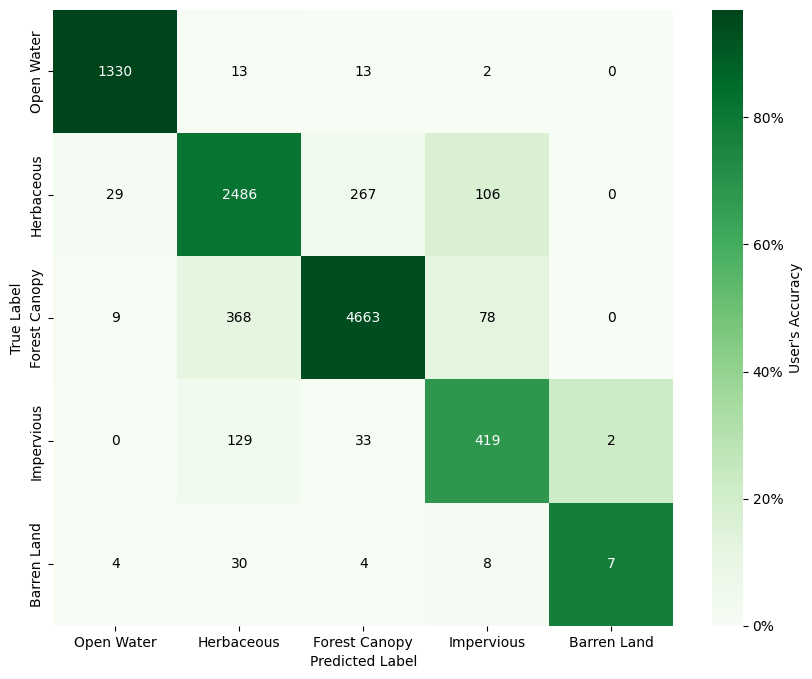

In [53]:
assessment_points_final['pred_lc_class'].value_counts()

confuision_matrix = confusion_matrix(assessment_points_final['lc_class'], assessment_points_final['pred_lc_class'])
print("Confusion Matrix:")
print(confuision_matrix)

cm_pred_norm = confusion_matrix(assessment_points_final['lc_class'], assessment_points_final['pred_lc_class'], normalize='pred')


print(classification_report(assessment_points_final['lc_class'], assessment_points_final['pred_lc_class']))

# pretty print the confusion matrix with class labels
class_labels = {
    1: 'Open Water',
    2: 'Herbaceous',
    3: 'Forest Canopy',
    4: 'Impervious',
    5: 'Barren Land',
}

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_pred_norm * 100, annot=False, fmt='.2%', cmap='Greens',
            xticklabels=[class_labels[i] for i in sorted(class_labels.keys())],
            yticklabels=[class_labels[i] for i in sorted(class_labels.keys())], ax=ax,
            cbar_kws={'label': 'User\'s Accuracy', 'format': '%.0f%%'})
sns.heatmap(confuision_matrix, annot=False, fmt='d', cmap='Greens', alpha=0.0,
            xticklabels=[class_labels[i] for i in sorted(class_labels.keys())],
            yticklabels=[class_labels[i] for i in sorted(class_labels.keys())], ax=ax, cbar=False)

# color text in the confusion matrix based off the true normalized confusion matrix values
for i in range(confuision_matrix.shape[0]):
    for j in range(confuision_matrix.shape[1]):
        value = confuision_matrix[i, j]
        norm_value = cm_pred_norm[i, j]
        if norm_value > 0.6:
            color = 'white'
        else:
            color = 'black'
        # elif norm_value > 0.2:
        #     color = 'black'
        # else:
        #     color = 'gray'
        ax.text(j + 0.5, i + 0.5, str(value), ha='center', va='center', color=color)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

# format classification report as a DataFrame for better visualization
report_dict = classification_report(assessment_points_final['lc_class'], assessment_points_final['pred_lc_class'], output_dict=True, target_names=[class_labels[i] for i in sorted(class_labels.keys())])
report_df = pd.DataFrame(report_dict).transpose()
report_df.index.name = 'Class'
report_df = report_df.rename(columns={
    'precision': 'User\'s Accuracy',
    'recall': 'Producer\'s Accuracy',
    'f1-score': 'F1 Score',
    'support': 'N'
})

report_df[["User's Accuracy", "Producer's Accuracy", "F1 Score"]] = report_df[["User's Accuracy", "Producer's Accuracy", "F1 Score"]].multiply(100).round(2)
report_df['N'] = report_df['N'].astype(int)

display(report_df)

In [ ]:
# combine CM and UA/PA into one table
cm_df = pd.DataFrame(confuision_matrix, index=[class_labels[i] for i in sorted(class_labels.keys())], columns=[class_labels[i] for i in sorted(class_labels.keys())])
cm_df['Producer\'s Accuracy'] = report_df['Producer\'s Accuracy'][:-3]
cm_df.loc['User\'s Accuracy'] = report_df['User\'s Accuracy']

overall_accuracy = report_df.loc['accuracy', 'precision']
cm_df.loc['User\'s Accuracy', 'Producer\'s Accuracy'] = report_df.loc['accuracy', 'precision']

,Open Water,Herbaceous,Forest Canopy,Impervious,Barren Land,Producer's Accuracy
Open Water,1330.00,13.00,13.00,2.00,0.00,97.94
Herbaceous,29.00,2486.00,267.00,106.00,0.00,86.08
Forest Canopy,9.00,368.00,4663.00,78.00,0.00,91.11
Impervious,0.00,129.00,33.00,419.00,2.00,71.87
Barren Land,4.00,30.00,4.00,8.00,7.00,13.21
User's Accuracy,96.94,82.15,93.63,68.35,77.78,NaN
